In [1]:
#                                           AF 6: Aprendizaje supervisado, árbol de decisión
# Integrantes
# 2121619 Yareli Nataly Herrera Milán     N5
# 2111019 Roberto Tadeo Vazquez Rodriguez N5
# 2178074 Esteban Capetillo Martínez      N5
# 2107169 Roberto Ortega Sandoval         N5
# 1911302 Ana Karen Cantú Hinojosa        N5

In [2]:
# 1.- IMPORTAR LIBRERIAS
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import numpy as np

In [3]:
# 2.- Carga y preparación de datos
cancer= load_breast_cancer() # Cargar el dataset de cáncer de mama incluido en 'sklearn.datasets'
X = cancer.data
y = cancer.target

In [4]:
# saber el número de registros
len(y)

569

In [5]:
# Obtiene la etiqueta (diagnóstico) del primer paciente del dataset
# 0 = maligno, 1 = benigno
y[0]

np.int64(0)

In [6]:
# Contiene los nombres de las clases del dataset
# En este caso: ['malignant', 'benign']
cancer.target_names

array(['malignant', 'benign'], dtype='<U9')

In [7]:
# 3.- Preprocesamiento de datos
#     Se dividen los datos en entrenamiento (80%) y prueba (20%)
#     X_train: datos para entrenar el modelo
#     X_test: datos para evaluar el modelo
#     y_train: etiquetas correspondientes al entrenamiento
#     y_test: etiquetas correspondientes a la prueba

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)


In [8]:
# 4.-  Selección y entrenamiento del modelo

# Se crea el modelo de Árbol de Decisión
modelo = DecisionTreeClassifier(random_state=42)

# Se entrena el modelo usando los datos de entrenamiento
modelo.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [9]:
# Exactitud del modelo en el entrenamiento.

# Calcula la exactitud (accuracy) del modelo usando los datos de entrenamiento
train_accuracy = modelo.score(X_train, y_train)

# Imprime el resultado
print( "Exactitud del modelo en el entrenamiento:", train_accuracy)


Exactitud del modelo en el entrenamiento: 1.0


In [10]:
# 5.- Prueba del modelo

# El modelo hace predicciones usando los datos de prueba
y_pred = modelo.predict(X_test)

In [11]:
# Obtener la matriz de confusión
# Calcula la matriz de confusión comparando valores reales vs predicciones
conf_matrix = confusion_matrix(y_test, y_pred)

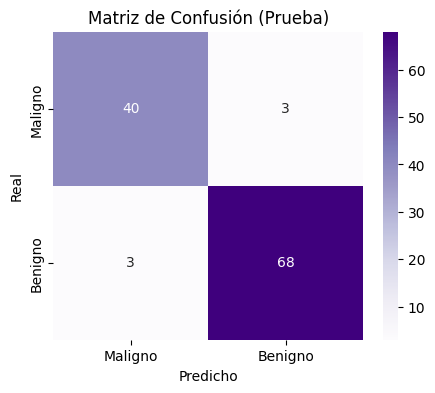

In [12]:
# Mostrar la matriz de confusión de resultados de la prueba

plt.figure(figsize=(5,4)) # Define el tamaño de la figura (ancho, alto)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Purples", xticklabels=['Maligno', 'Benigno'],yticklabels=['Maligno', 'Benigno'])
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión (Prueba)")
plt.show()


In [13]:
#PREDICCION 1

print(y_pred[1]) # Muestra lo que el modelo predijo para el segundo dato de prueba
print(y_test[1]) # Muestra el valor real (la respuesta correcta) de ese mismo dato

0
0


In [14]:
#PREDICCION 2
print(y_pred[20])
print(y_test[20])


1
0


In [15]:
#PREDICCION 3
print(y_pred[-1])
print(y_test[-1])

0
0


In [16]:
accuracy = accuracy_score(y_test, y_pred) # Calcula la exactitud del modelo
print("Accuracy:", accuracy)              # Imprime el accuracy
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=cancer.target_names
))                                        # Muestra un reporte más completo de evaluación del modelo

Accuracy: 0.9473684210526315
Classification Report:
               precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        43
      benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



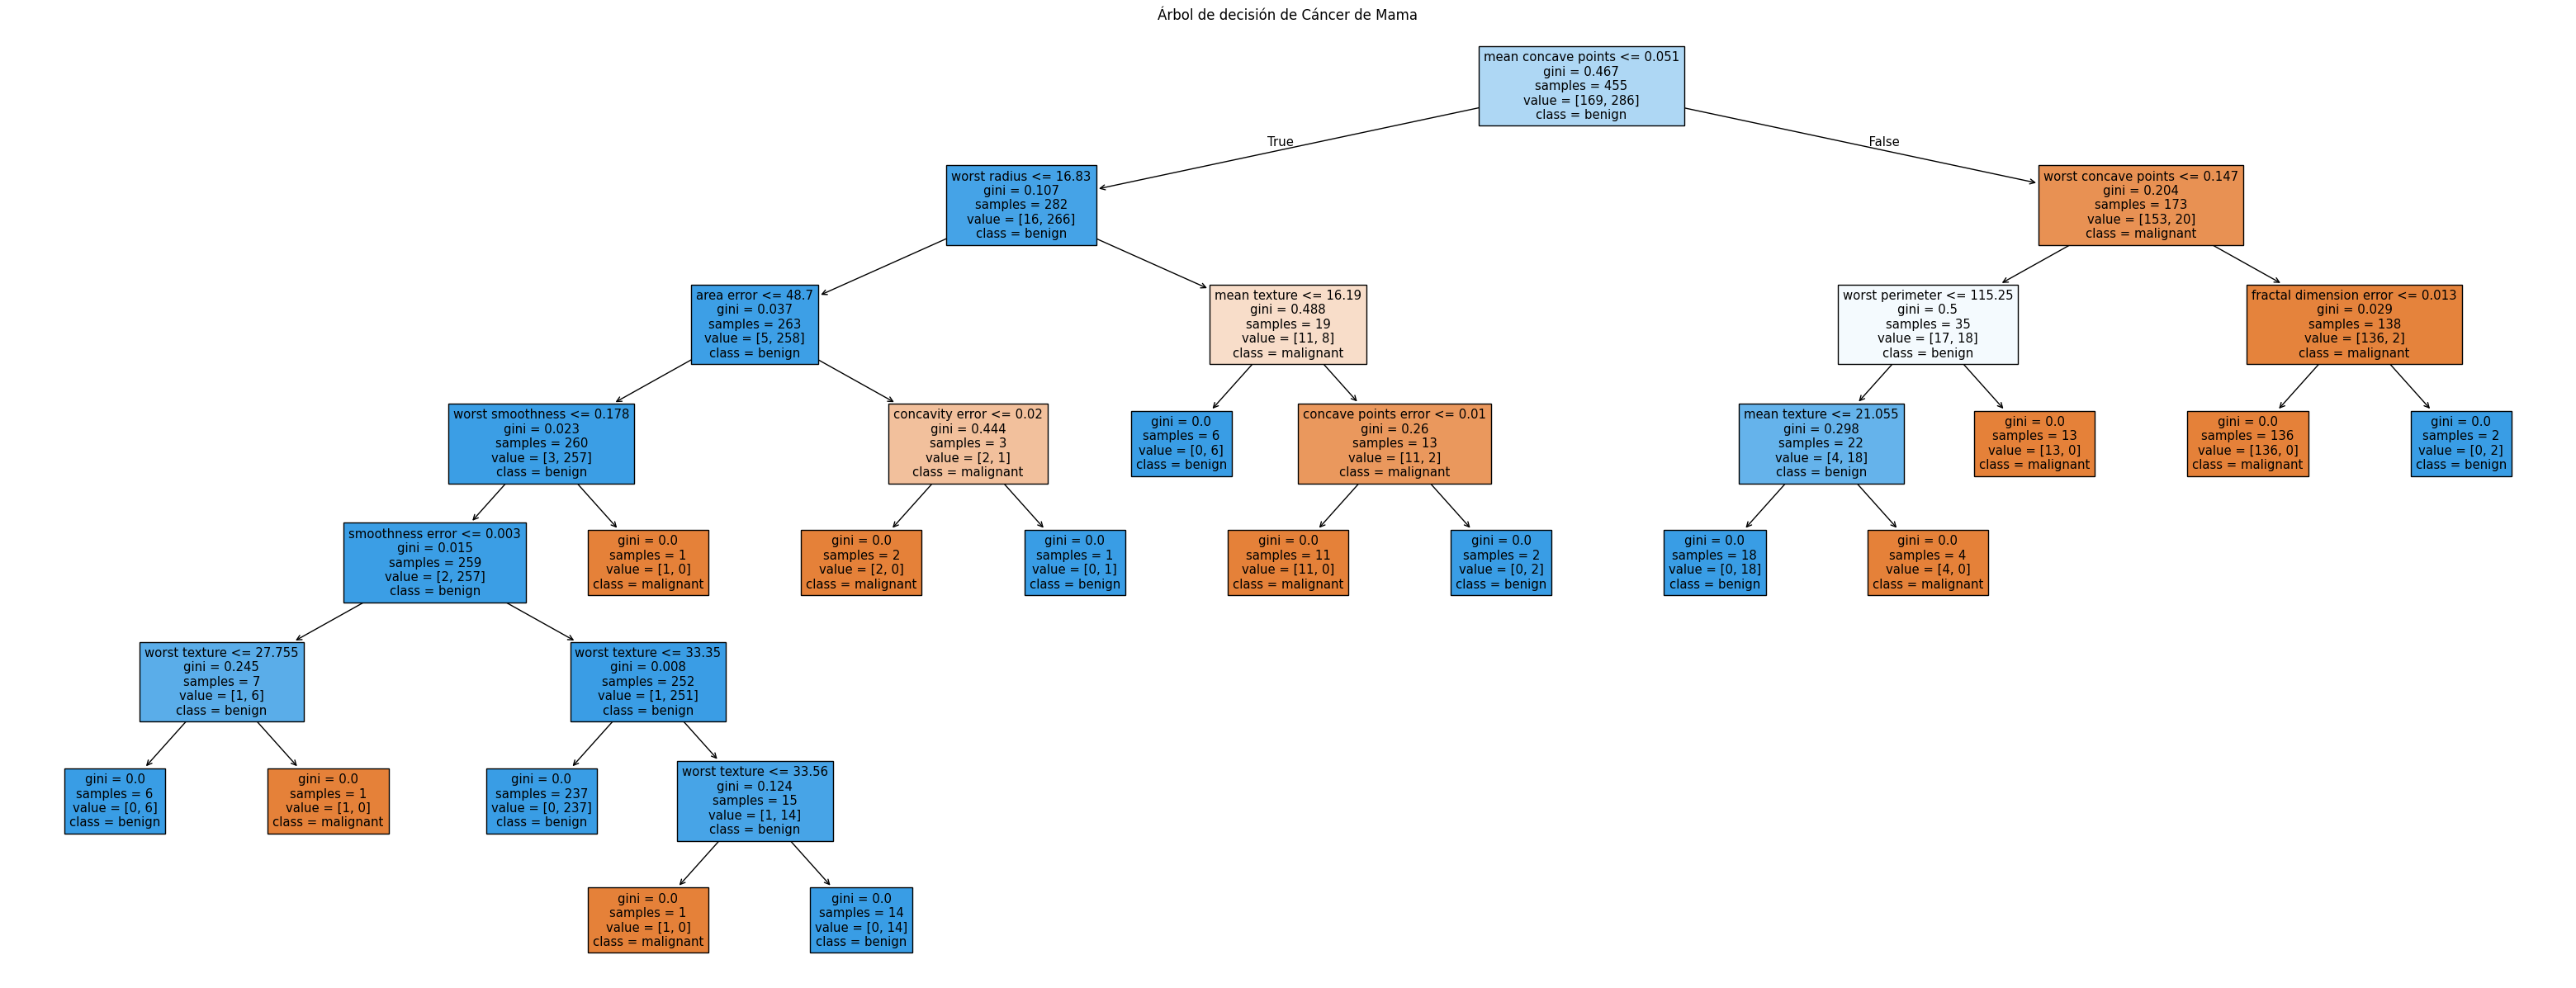

In [17]:
# 6.- Visualización del árbol de decisión.  Con DPI de 300

plt.figure(figsize=(40, 15)) # Define el tamaño de la figura
tree.plot_tree(modelo, filled=True, feature_names=cancer.feature_names, class_names=cancer.target_names) # Dibuja el árbol de decisión
plt.title("Árbol de decisión de Cáncer de Mama")
plt.savefig("decision_tree.png", dpi=300) # Guarda la imagen en un archivo PNG con buena resolución
plt.show()
